# Deep Learning for Player Action Prediction from Atari Gameplay Frames

**Student:** Robert Mayfield  
**Course:** Udacity AI Masters Capstone, Project 4: Deep Learning Systems

---

In [ ]:
import sys
import io
import json
import zipfile
import tarfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

# project utilities — all dl_utils imports consolidated here
from src.dl_utils import (
    load_all_sessions,
    GameFrameDataset,
    SessionAwareStackedDataset,
    ActionCNN,
    train_one_epoch,
    eval_epoch,
    evaluate_model,
    save_checkpoint,
    load_checkpoint,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device:  {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU:     {torch.cuda.get_device_name(0)}')

In [6]:
%matplotlib inline

In [7]:
PROJECT_ROOT   = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

ATARI_ZIP      = PROJECT_ROOT / 'data' / 'raw' / 'montezuma_revenge.zip'
FIGURES_DIR    = PROJECT_ROOT / 'outputs' / 'figures'
TABLES_DIR     = PROJECT_ROOT / 'outputs' / 'tables'
ARTIFACTS_DIR  = PROJECT_ROOT / 'outputs' / 'model_artifacts'
SAMPLE_DIR     = PROJECT_ROOT / 'data' / 'sample'

for d in [FIGURES_DIR, TABLES_DIR, ARTIFACTS_DIR, SAMPLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE     = 84
STACK_SIZE   = 4
BATCH_SIZE   = 64
EPOCHS       = 30
LR           = 1e-4
N_ACTIONS    = 5
ACTION_NAMES = ['NOOP', 'RIGHT', 'LEFT', 'UP', 'DOWN']

ALE_TO_CLASS = {
    0: 0, 1: 0,                               # NOOP, FIRE -> NOOP
    3: 1, 6: 1, 8: 1, 11: 1, 14: 1, 16: 1,   # rightward moves and fire combos
    4: 2, 7: 2, 9: 2, 12: 2, 13: 2, 15: 2,   # leftward moves and fire combos
    2: 3, 10: 3,                               # UP, UPFIRE -> UP
    5: 4,                                      # DOWN
}

print(f'ZIP found: {ATARI_ZIP.exists()}')
print('Configuration ready.')

ZIP found: True
Configuration ready.


## 1. Project Overview

This project trains a convolutional neural network to predict player actions from Atari Montezuma's Revenge gameplay frames using real human demonstration data. Montezuma's Revenge is a side scrolling platformer requiring jumping, ladder climbing, key collection, and hazard avoidance. This is directly relevant to the platformer behavior modeling goals of the AI Game Director Studio.

**Research question:** Does providing the model with four consecutive frames of temporal context improve action prediction over a single static frame?

**Dataset:** Atari-HEAD (Zhang et al., 2020) - 27 sessions, 447,327 frames, one human player.

**Controlled comparison:** Baseline uses a single frame (in_channels=1). Experimental model uses four stacked consecutive frames (in_channels=4). Architecture, optimizer, loss function, and training duration are held constant.

**Primary metric:** Macro F1, because UP and DOWN are mild minority classes (~10% each). Accuracy is reported as a secondary metric.

## 2. Dataset Loading and Inspection

In [ ]:
print('Loading all Montezuma Revenge sessions from zip archive...')
print('All frames are preloaded to CPU RAM as uint8 (normalisation deferred to DataLoader).')
print()

frames, labels, session_lengths, session_meta = load_all_sessions(
    zip_path=ATARI_ZIP,
    img_size=IMG_SIZE,
    ale_to_class=ALE_TO_CLASS,
)

print()
print(f'Total frames loaded : {len(frames):>10,}')
print(f'Total sessions      : {len(session_meta):>10}')
print(f'Frame array shape   : {str(frames.shape):>10}')
print(f'Frame dtype         : {str(frames.dtype):>10}')
print(f'Label dtype         : {str(labels.dtype):>10}')
print(f'RAM usage (uint8)   : {frames.nbytes / 1024**3:>9.2f} GB')

In [9]:
# Session summary table
session_df = pd.DataFrame(session_meta)
session_df.index = range(1, len(session_df) + 1)
session_df.columns = ['Session', 'Type', 'Frames']
session_df = session_df[['Session', 'Type', 'Frames']]

print(f'{"#":<4} {"Type":<12} {"Frames":>8}   Session')
print('-' * 70)
for i, row in session_df.iterrows():
    print(f'{i:<4} {row["Type"]:<12} {row["Frames"]:>8,}   {row["Session"]}')
print('-' * 70)
print(f'{"TOTAL":<17} {sum(session_lengths):>8,}')
print(f'\nStandard sessions : {sum(1 for m in session_meta if m["type"] == "standard")}')
print(f'Highscore sessions: {sum(1 for m in session_meta if m["type"] == "highscore")}')
print(f'Min frames/session: {min(session_lengths):,}')
print(f'Max frames/session: {max(session_lengths):,}')
print(f'Avg frames/session: {sum(session_lengths)/len(session_lengths):,.0f}')

#    Type           Frames   Session
----------------------------------------------------------------------
1    standard       15,651   284_RZ_5540489_Apr-17-17-38-18
2    standard       16,494   285_RZ_5619207_Apr-18-15-28-46
3    standard       16,194   287_RZ_7172481_May-06-14-59-10
4    standard       16,721   291_RZ_7364933_May-08-20-23-25
5    standard       15,895   324_RZ_452975_Jun-13-14-10-23
6    standard       16,687   333_RZ_900705_Jun-18-18-32-58
7    standard       17,053   340_RZ_1323550_Jun-23-15-59-54
8    standard       17,096   359_RZ_1993616_Jul-01-10-09-26
9    standard       17,067   365_RZ_2079996_Jul-02-10-07-22
10   standard       16,547   371_RZ_2173469_Jul-03-12-05-16
11   standard       16,956   385_RZ_2344725_Jul-05-11-46-58
12   standard       16,883   398_RZ_2530473_Jul-07-15-16-40
13   standard       17,054   402_RZ_2603283_Jul-08-11-28-49
14   standard       16,992   416_RZ_2788252_Jul-10-14-52-12
15   standard       16,935   429_RZ_2945490_Jul-12-10-

In [10]:
# Frame property inspection
print('Frame pixel statistics:')
sample_idx = np.random.default_rng(SEED).integers(0, len(frames), size=10_000)
sample = frames[sample_idx].astype(np.float32)
print(f'  Min pixel value  : {frames.min()}')
print(f'  Max pixel value  : {frames.max()}')
print(f'  Mean (10k sample): {sample.mean():.2f}')
print(f'  Std  (10k sample): {sample.std():.2f}')
print()
print('Label value range:')
print(f'  Unique labels: {sorted(np.unique(labels).tolist())}')
print(f'  Expected     : {list(range(N_ACTIONS))} ({ACTION_NAMES})')

Frame pixel statistics:
  Min pixel value  : 0
  Max pixel value  : 235
  Mean (10k sample): 42.14
  Std  (10k sample): 51.45

Label value range:
  Unique labels: [0, 1, 2, 3, 4]
  Expected     : [0, 1, 2, 3, 4] (['NOOP', 'RIGHT', 'LEFT', 'UP', 'DOWN'])


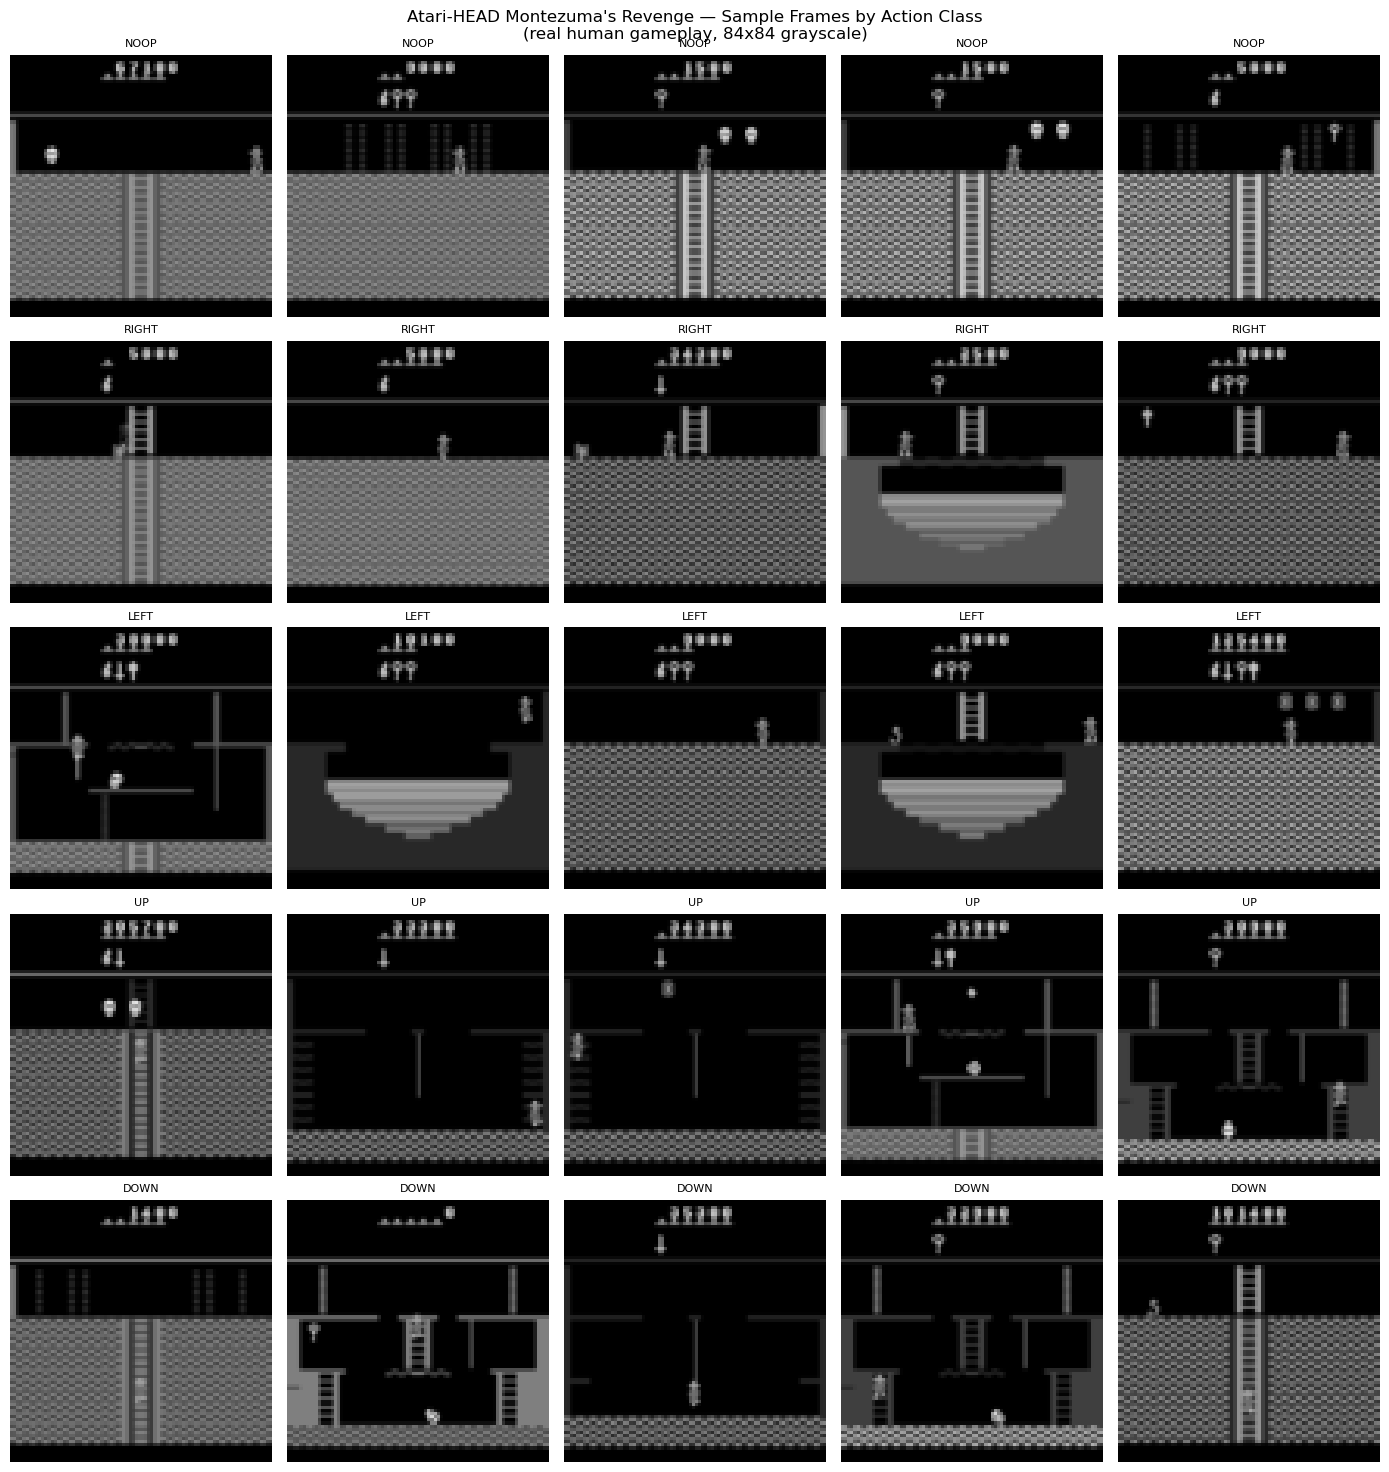

Figure saved to outputs/figures/sample_frames_by_class.png


In [11]:
# Sample frames — one row per action class showing representative gameplay moments
fig, axes = plt.subplots(N_ACTIONS, 5, figsize=(14, 3 * N_ACTIONS))

for cls in range(N_ACTIONS):
    cls_indices = np.where(labels == cls)[0]
    chosen = np.random.default_rng(SEED + cls).choice(cls_indices, size=5, replace=False)
    for col, idx in enumerate(chosen):
        ax = axes[cls, col]
        ax.imshow(frames[idx], cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{ACTION_NAMES[cls]}', fontsize=8)
        ax.axis('off')

fig.suptitle(
    'Atari-HEAD Montezuma\'s Revenge — Sample Frames by Action Class\n'
    '(real human gameplay, 84x84 grayscale)',
    fontsize=12,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'sample_frames_by_class.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/sample_frames_by_class.png')

**Dataset inspection findings.** All 447,327 frames loaded successfully across 27 sessions. Frames are stored as 84x84 grayscale uint8 arrays (~3.2 GB total in CPU RAM), with pixel values ranging from 0 to 255. All five action classes are present in the label array. The sample frames show recognizable Montezuma's Revenge gameplay elements: the starting room with ladders, platforms, keys, and the skull enemy. Visual differences between action classes are subtle in static frames, which motivates a four frame stacking approach in the experimental model. No missing frames or label anomalies were detected during loading.

## 3. Data Preprocessing

In [12]:
# placeholder — implemented in Section 3

## 4. Label Distribution and Class Imbalance

In [13]:
# placeholder — implemented in Section 4

## 5. Baseline Model Implementation

In [14]:
# placeholder — implemented in Section 5

## 6. Baseline Model Training

In [15]:
# placeholder — implemented in Section 6

## 7. Experimental Comparison Design

In [16]:
# placeholder — implemented in Section 7

## 8. Experimental Model Training

In [17]:
# placeholder — implemented in Section 8

## 9. Evaluation and Comparison

In [18]:
# placeholder — implemented in Section 9

## 10. Error Analysis and Failure Cases

In [19]:
# placeholder — implemented in Section 10

## 11. Limitations, Risks, and Responsible Use

placeholder — written in Section 11

## 12. Future Integration with AI Game Director Studio

placeholder — written in Section 12

## 13. Final Notebook Summary

placeholder — written in Section 13

## References

placeholder — written at end